In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('data/wine_quality_merged.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [39]:
num_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',]

In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [36]:
df.isna().sum().sort_values(ascending=False) # any missed valuesdf.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [35]:
df.describe(include='all').T #return tables

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,NaN,NaN,NaN,7.215307,1.296434,3.8,6.4,7.0,7.7,15.9
volatile acidity,6497.0,NaN,NaN,NaN,0.339666,0.164636,0.08,0.23,0.29,0.4,1.58
citric acid,6497.0,NaN,NaN,NaN,0.318633,0.145318,0.0,0.25,0.31,0.39,1.66
residual sugar,6497.0,NaN,NaN,NaN,5.443235,4.757804,0.6,1.8,3.0,8.1,65.8
chlorides,6497.0,NaN,NaN,NaN,0.056034,0.035034,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,NaN,NaN,NaN,30.525319,17.7494,1.0,17.0,29.0,41.0,289.0
total sulfur dioxide,6497.0,NaN,NaN,NaN,115.744574,56.521855,6.0,77.0,118.0,156.0,440.0
density,6497.0,NaN,NaN,NaN,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,NaN,NaN,NaN,3.218501,0.160787,2.72,3.11,3.21,3.32,4.01
sulphates,6497.0,NaN,NaN,NaN,0.531268,0.148806,0.22,0.43,0.51,0.6,2.0


In [20]:
df.shape

(6497, 13)

In [21]:
df = df.drop_duplicates()
df = df.dropna()

In [43]:
# data cleaning
df = df.fillna(df.median(numeric_only=True))
df = df.apply(lambda col: col.fillna(col.mode()[0]) if col.dtype=='object' else col)

In [22]:
df.shape

(5320, 13)

In [23]:
df["type_white"] = (df["type"] == "white").astype(int)
df = df.drop(columns='type')

In [44]:
df = pd.get_dummies(df, drop_first=True)

artur
### Now before jumping straight to the training lets explore categories (to be fixed for a single plot)

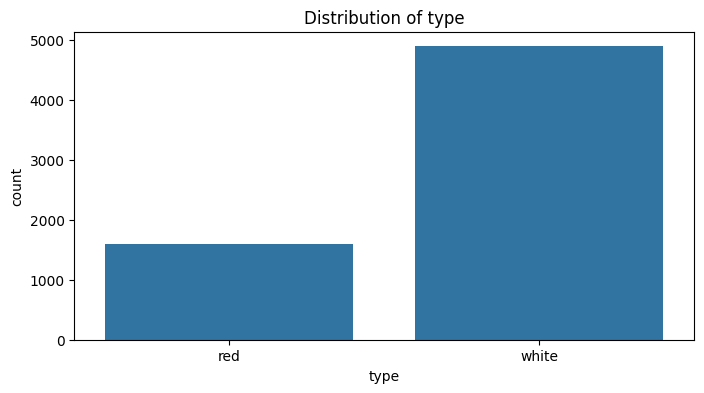

In [42]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

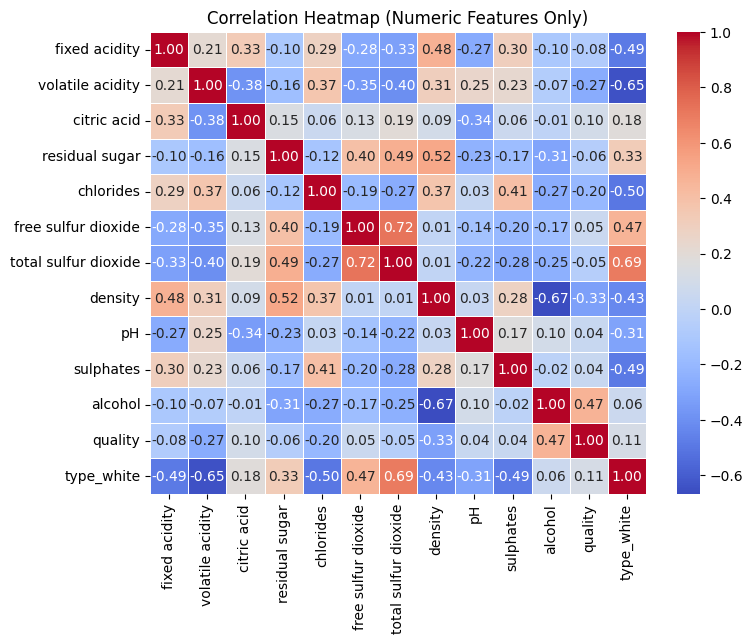

In [24]:
numeric_df = df.select_dtypes(include=[np.number])

matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

note artur

### First we gotta visually show what are the values that give most of the points to the Tasteness of the wine

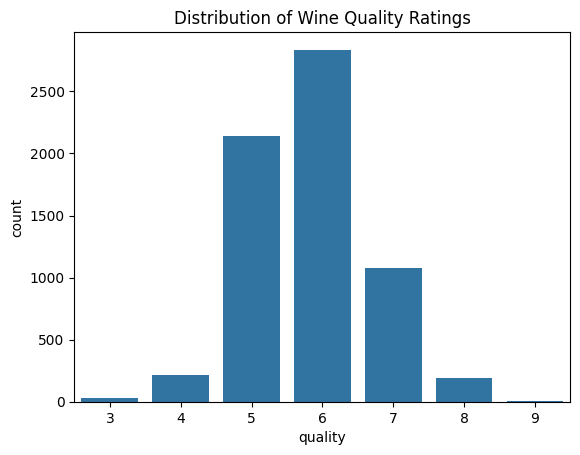

In [ ]:
# Lets target variable 
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality Ratings')
plt.show()


# Well we gotta further provide the data so

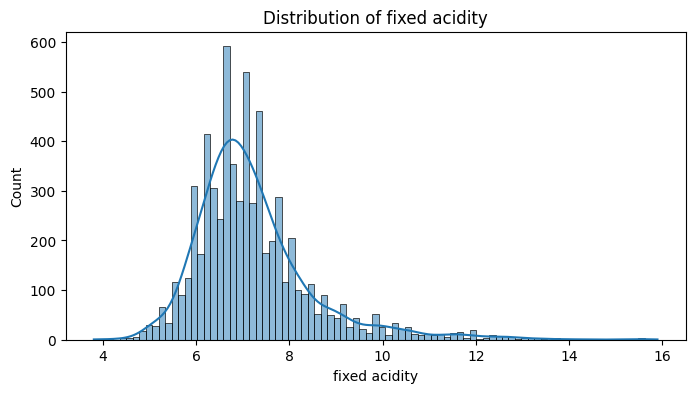

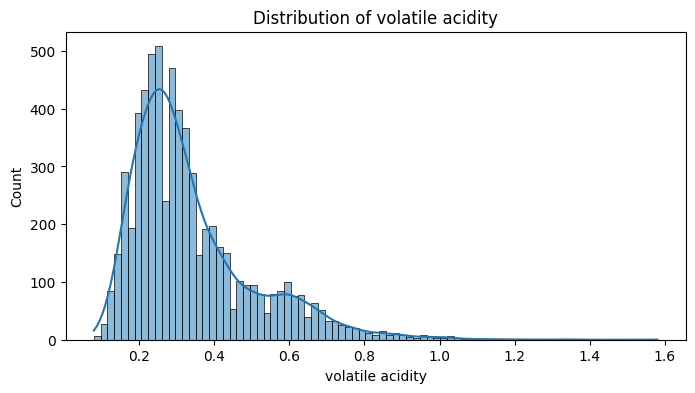

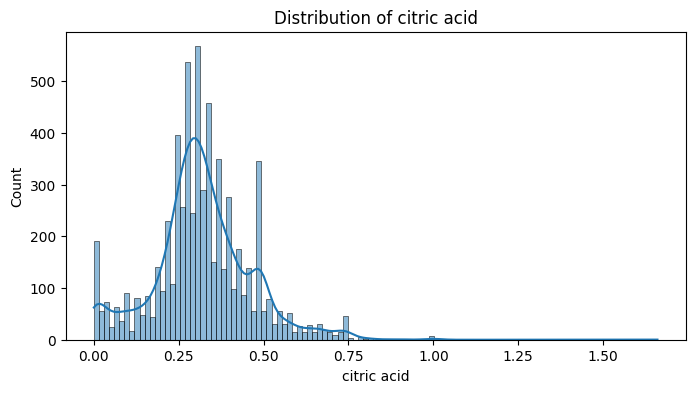

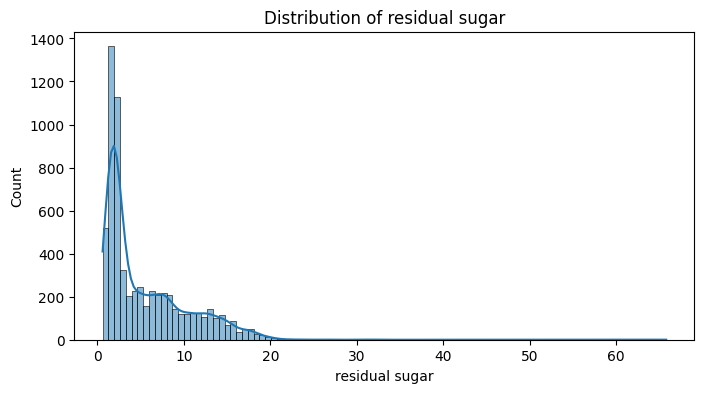

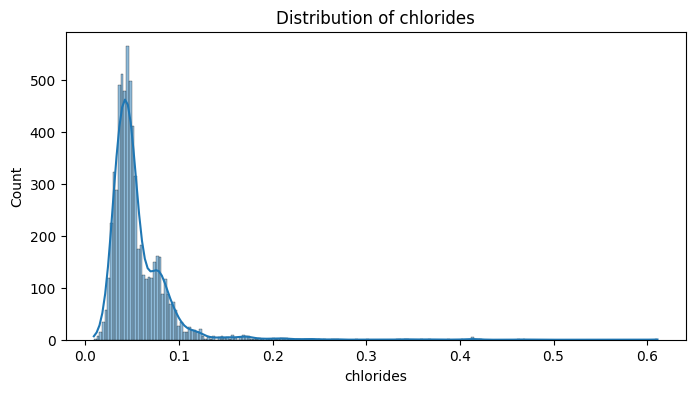

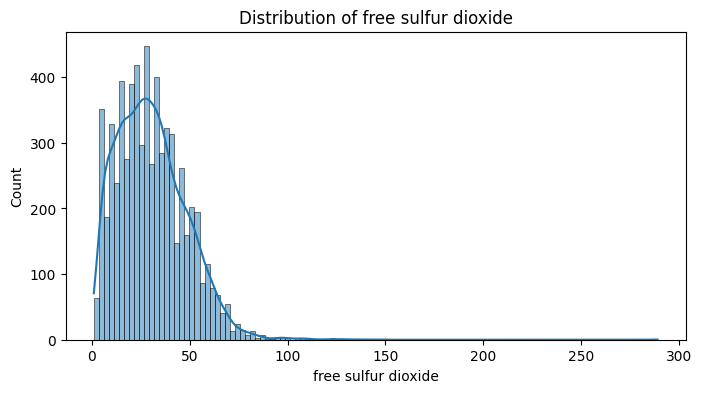

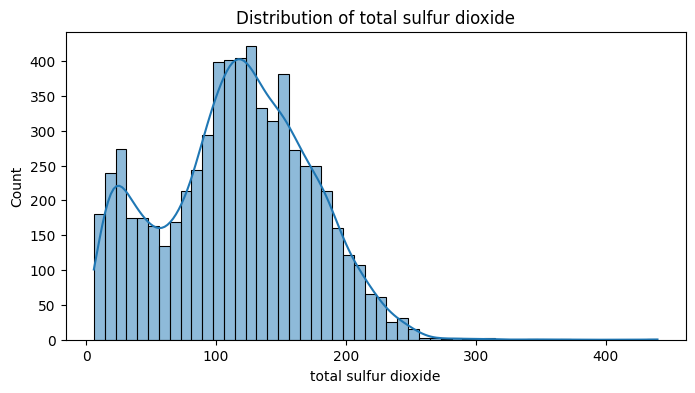

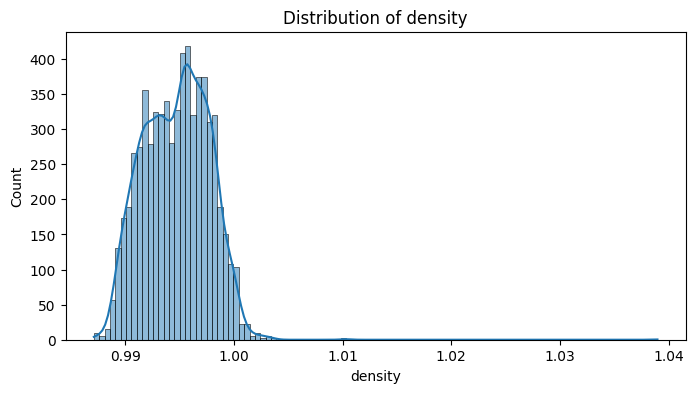

In [48]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Data cleaning done
# ----------------------------------------------------------------

### here we can see that sulfur dioxide and free sulfur dioxide hight corr 0.72
### keep total sulfur dioxide, drop free sulfur dioxide, or vice versa-> we can drop free sulfur dioxide

Keep: total sulfur dioxide
Drop: free sulfur dioxide

Why?

Total SO₂ = overall level
It includes both free and bound forms, so it’s a more global indicator of how much sulfur dioxide is in the wine.

Free SO₂ is a subset
It’s important chemically, but from a statistical point of view it’s usually strongly correlated with total SO₂ and doesn’t add a lot of extra signal on top of it in a simple model.

In [ ]:
# df = df.drop(columns='free sulfur dioxide')

In [ ]:
# df_quality = df["quality"].value_counts(ascending=True)

In [96]:
# def map_quality(q):
#     if q <= 5:          # 3, 4, 5
#         return "good"
#     else:        # 6
#         return "not good"

df["quality"] = df["quality"].apply(map_quality)
# df = df.drop(columns='quality')

# How do i actually calculate quality here?
X = df.drop(columns='quality')
y = df['quality']
df_cols = X.columns
X = X.values
y = y.values


KeyError: 'quality'

In [ ]:
# df["quality_level"].value_counts()

quality_level
not good    3332
good        1988
Name: count, dtype: int64

In [ ]:
# df_cols = df.columns --- This will not get the actuall info. We need to fetch the one from the dataframe

df_cols = 

# Stage 2. Data training and evaluation


In [95]:
from sklearn.linear_model import LogisticRegression

y = df['quality']  # Keep all quality values
X = df.drop(columns='quality')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=10000, multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Also check class distribution
print(y.value_counts().sort_index())

KeyError: 'quality'

In [ ]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


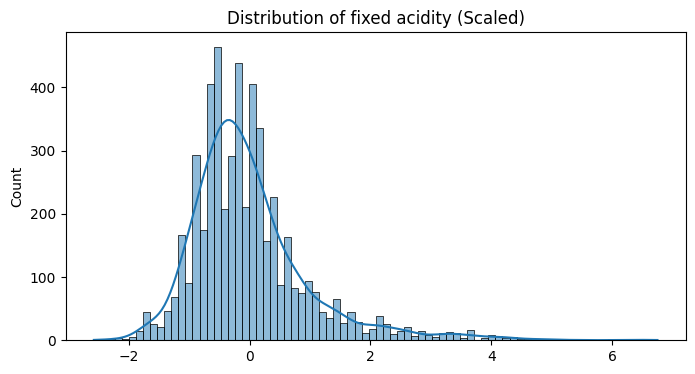

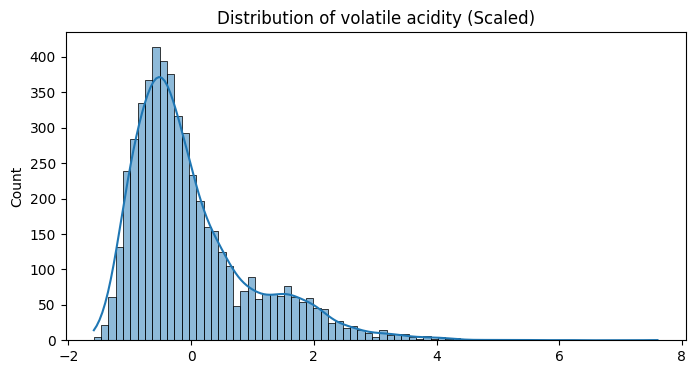

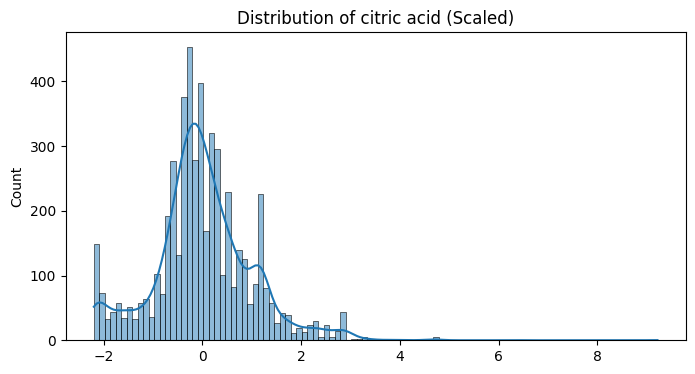

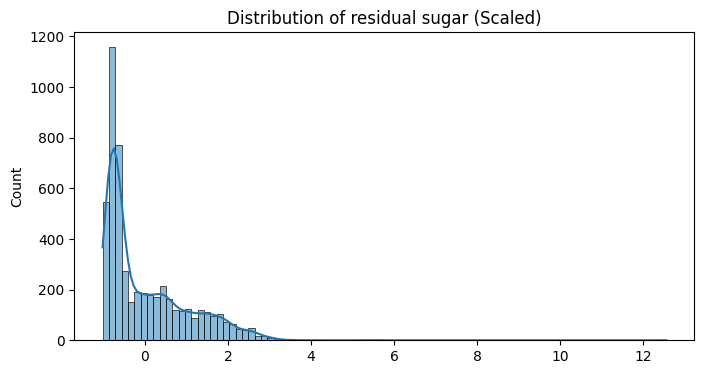

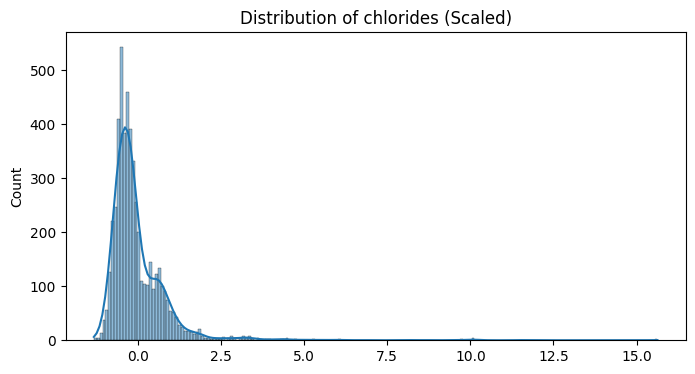

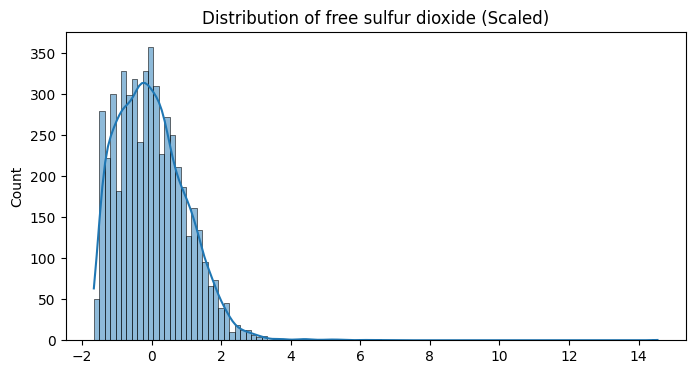

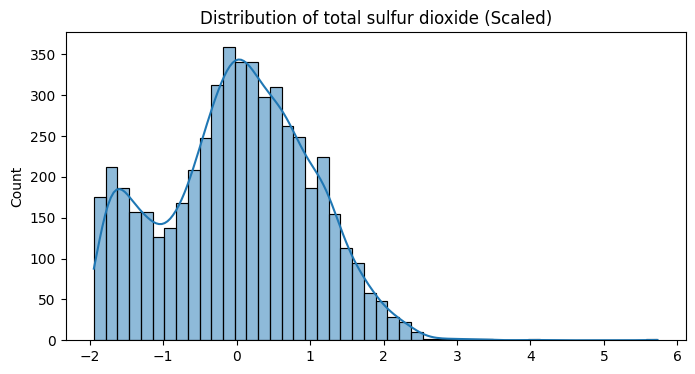

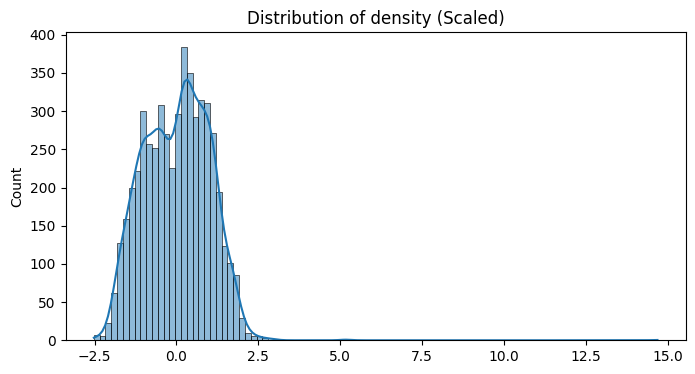

In [93]:
# Lets plot again
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[:, df_cols.get_loc(col)], kde=True)
    plt.title(f'Distribution of {col} (Scaled)')
    plt.show()